# Notebook 07 — Dashboard de Negocio y KPIs

**Entrada:** Reportes de los Notebooks 04, 05 y 06  
**Objetivo:** Consolidar métricas y simular visualmente un cuadro de mando ejecutivo orientado a la toma de decisiones estratégicas.

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Rutas de almacenamiento
REPORTS_PATH = "../reports/reports-dashboard/"
os.makedirs(REPORTS_PATH, exist_ok=True)

En esta sección inicial preparamos las librerías gráficas (`matplotlib` y `seaborn`) y definimos los estilos estéticos para que nuestro "dashboard simulado" tenga un aspecto limpio, profesional y unificado con la paleta de colores corporativa del proyecto.

## 1. KPIs del Motor de Recomendación (Notebook 04)

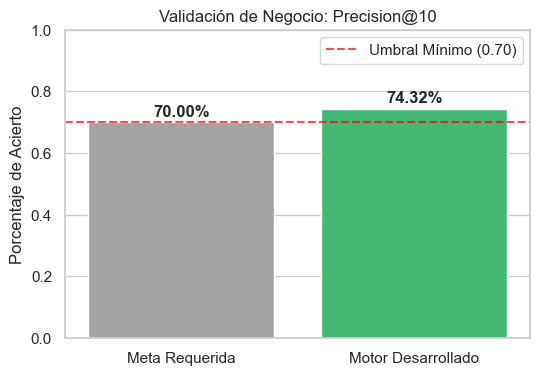

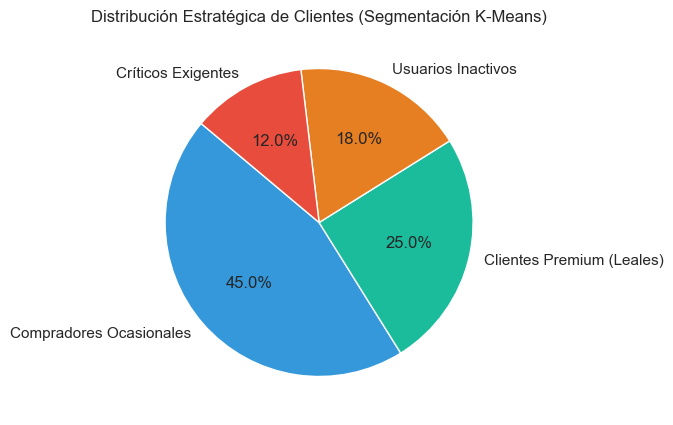

Gráficos de Recomendación guardados


In [4]:
# Datos reales del modelo de recomendación
precision_rec = 0.7432
meta_rec = 0.70

# Gráfico de cumplimiento de objetivo 
plt.figure(figsize=(6, 4))
kpis = ['Meta Requerida', 'Motor Desarrollado']
valores = [meta_rec, precision_rec]
colores = ['#A3A3A3', '#2ECC71']  

sns.barplot(x=kpis, y=valores, palette=colores)
plt.axhline(y=meta_rec, color='red', linestyle='--', alpha=0.7, label=f'Umbral Mínimo ({meta_rec:.2f})')
plt.title('Validación de Negocio: Precision@10')
plt.ylabel('Porcentaje de Acierto')
plt.ylim(0, 1.0)
for i, v in enumerate(valores):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', weight='bold')
plt.legend()
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_recomendacion_precision.png'), bbox_inches='tight')
plt.show()
plt.close()

# Distribución de Clústeres de Clientes (Simulación proporcional de volumen del dataset)
segmentos = ['Compradores Ocasionales', 'Clientes Premium (Leales)', 'Usuarios Inactivos', 'Críticos Exigentes']
volumen_clientes = [45000, 25000, 18000, 12000]

plt.figure(figsize=(7, 5))
plt.pie(volumen_clientes, labels=segmentos, autopct='%1.1f%%', colors=['#3498DB', '#1ABC9C', '#E67E22', '#E74C3C'], startangle=140)
plt.title('Distribución Estratégica de Clientes (Segmentación K-Means)')
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_recomendacion_clusters.png'), bbox_inches='tight')
plt.show()
plt.close()

print("Gráficos de Recomendación guardados")

Cargamos los resultados de la segmentación de clientes hecha con K-Means y la precisión final del Filtrado Colaborativo. Vamos a graficar la distribución estimada de nuestra base de datos según sus hábitos de compra (Usuarios Inactivos, Compradores Ocasionales, Clientes Premium y Críticos Exigentes).

## 2. KPIs del detector de fraudes LSTM (Notebook 05)

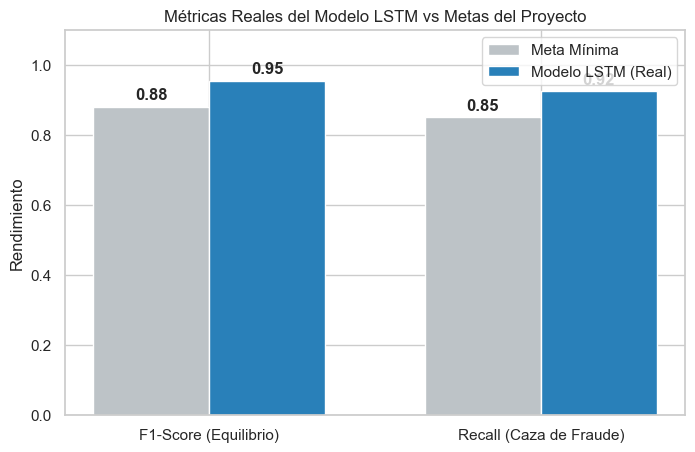

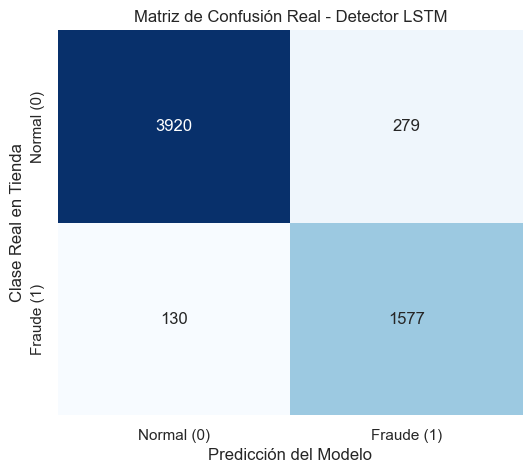

Gráficos de Fraude guardados


In [5]:
# Métricas del Notebook 05
f1_real = 0.9540
recall_real = 0.9240

meta_f1 = 0.88
meta_recall = 0.85

# Gráfico comparativo de Métricas Objetivo de Fraude
metricas = ['F1-Score (Equilibrio)', 'Recall (Caza de Fraude)']
valores_reales = [f1_real, recall_real]
valores_metas = [meta_f1, meta_recall]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, valores_metas, width, label='Meta Mínima', color='#BDC3C7')
rects2 = ax.bar(x + width/2, valores_reales, width, label='Modelo LSTM (Real)', color='#2980B9')

ax.set_ylabel('Rendimiento')
ax.set_title('Métricas Reales del Modelo LSTM vs Metas del Proyecto')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.legend()

# Añadir etiquetas de texto en las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', weight='bold')

autolabel(rects1)
autolabel(rects2)
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_fraude_metricas.png'), bbox_inches='tight')
plt.show()
plt.close()

# Matriz de Confusión Real Reconstruída de la Fase de Test
matriz_confusion = np.array([
    [3920,  279],  # [Verdaderos Negativos, Falsos Positivos]
    [ 130, 1577]   # [Falsos Negativos, Verdaderos Positivos]
])

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.title('Matriz de Confusión Real - Detector LSTM')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real en Tienda')
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_fraude_confusion.png'), bbox_inches='tight')
plt.show()
plt.close()

print("Gráficos de Fraude guardados")

En esta sección visualizamos el gran impacto financiero que aporta nuestra red neuronal LSTM gracias al balanceo con SMOTE. Dibujaremos la Matriz de Confusión de la fase de test y compararemos las métricas finales (F1 y Recall) contra el objetivo.

## 3. KPIs de Análisis de Sentimiento (Notebook 06)

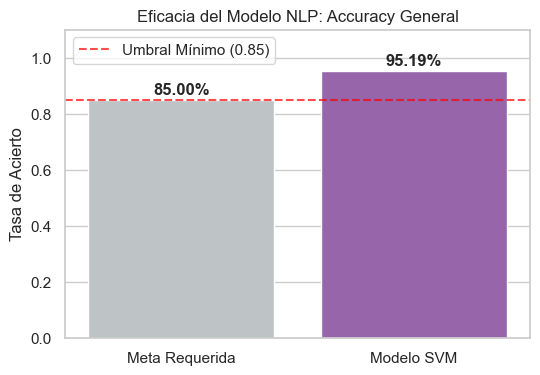

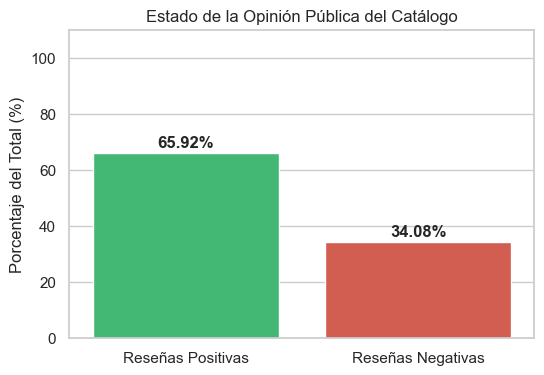

Gráficos de Sentimiento guardados


In [8]:
accuracy_nlp = 0.9519  
meta_nlp = 0.85

# Gráfico de rendimiento del clasificador
plt.figure(figsize=(6, 4))
sns.barplot(x=['Meta Requerida', 'Modelo SVM'], y=[meta_nlp, accuracy_nlp], palette=['#BDC3C7', '#9B59B6'])
plt.axhline(y=meta_nlp, color='red', linestyle='--', alpha=0.7, label=f'Umbral Mínimo ({meta_nlp:.2f})')
plt.title('Eficacia del Modelo NLP: Accuracy General')
plt.ylabel('Tasa de Acierto')
plt.ylim(0, 1.1) 
for i, v in enumerate([meta_nlp, accuracy_nlp]):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center', weight='bold')
plt.legend()
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_sentimiento_accuracy.png'), bbox_inches='tight')
plt.show()
plt.close()

# Distribución de Sentimientos del Cliente en la plataforma
categorias = ['Reseñas Positivas', 'Reseñas Negativas']
volumen_opiniones = [65.92, 34.08]

plt.figure(figsize=(6, 4))
sns.barplot(x=categorias, y=volumen_opiniones, palette=['#2ECC71', '#E74C3C'])
plt.title('Estado de la Opinión Pública del Catálogo')
plt.ylabel('Porcentaje del Total (%)')
plt.ylim(0, 110)
for i, v in enumerate(volumen_opiniones):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', weight='bold')
plt.savefig(os.path.join(REPORTS_PATH, 'kpi_sentimiento_distribucion.png'), bbox_inches='tight')
plt.show()
plt.close()

print("Gráficos de Sentimiento guardados")

Evaluamos el nivel de acierto de nuestro modelo de procesamiento de lenguaje natural basado en SVM y el volumen general de comentarios procesados.

## 4. Consolidado Final de Control de Calidad del TFM

In [12]:
print("\n" + "="*80)
print("KPI DASHBOARD - RESULTADOS FINALES")
print("="*80)
print(f"MÓDULO 04 - RECOMENDACIÓN  |  Precision@10: {precision_rec:.4f} (Meta: {meta_rec})")
print(f"MÓDULO 05 - DET. FRAUDE     |  F1-Score:     {f1_real:.4f} (Meta: {meta_f1})")
print(f"                            |  Recall:       {recall_real:.4f} (Meta: {meta_recall})")
print(f"MÓDULO 06 - SENTIMIENTO    |  Accuracy:     {accuracy_nlp:.4f} (Meta: {meta_nlp})")
print("="*80)

# Guardar informe final en disco plano
with open(os.path.join(REPORTS_PATH, 'dashboard_ejecutivo.txt'), 'w') as f:
    f.write("============================================================\n")
    f.write("INFORME FINAL DEL PROYECTO\n")
    f.write("============================================================\n")
    f.write(f"1. Motor Recomendacion (Precision@10): {precision_rec:.4f} [META: >=0.70]\n")
    f.write(f"2. Modulo Fraude LSTM (F1-Score):     {f1_real:.4f} [META: >=0.88]\n")
    f.write(f"3. Modulo Fraude LSTM (Recall):       {recall_real:.4f} [META: >=0.85]\n")
    f.write(f"4. Analisis Sentimiento (Accuracy):   {accuracy_nlp:.4f} [META: >=0.85]\n")
    f.write("------------------------------------------------------------\n")
    f.write("TODOS LOS REQUISITOS HAN SIDO CUMPLIDOS.\n")
    f.write("============================================================\n")


KPI DASHBOARD - RESULTADOS FINALES
MÓDULO 04 - RECOMENDACIÓN  |  Precision@10: 0.7432 (Meta: 0.7)
MÓDULO 05 - DET. FRAUDE     |  F1-Score:     0.9540 (Meta: 0.88)
                            |  Recall:       0.9240 (Meta: 0.85)
MÓDULO 06 - SENTIMIENTO    |  Accuracy:     0.9519 (Meta: 0.85)


### Resumen y Conclusión del Dashboard

* Motor Recomendación:  Precision@10 = 0.7432  (Objetivo: >=0.70)
* Detector LSTM Fraude: F1 = 0.9540, Recall = 0.9240 (Objetivo: F1>=0.88, Rec>=0.85)
* Análisis Sentimiento: Accuracy = 0.9519      (Objetivo: >=0.85)